In [2]:
import io
import os
import json
import pandas as pd
import numpy as np
from datetime import datetime as dt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import plotly.express as px
from IPython.display import HTML
from IPython.display import Image
import warnings
warnings.filterwarnings('ignore')

from sparky_bc import Sparky
# files lz conection
path_sparky_conf = '/Users/santlond/Documents/sparky_conf.json'

# Configurar conexión a LZ
with open(path_sparky_conf, 'rb') as JSON_lz_File:
    sp_config = json.loads(JSON_lz_File.read())
    
USER='santlond'
PASS=sp_config['ID']
DSN='IMPALA_PROD'
LOGDIR= 'logs'
# sparky = Sparky(username=USER, password=PASS, dsn=DSN, hostname="sbmdeblze004.bancolombia.corp")
sparky = Sparky(username=USER, password=PASS, dsn=DSN, hostname="sbmdeblze004.bancolombia.corp", spark_submit="spark3-submit")
 
# sparky = Sparky(username=USER, password=PASS, dsn=DSN)

helper = sparky.helper

2026-07-16 09:05:12 - [WARNING] - No se encontro la carpeta "/Users/santlond/Documents/mmm_tdc/logs" para guardar los logs


 ____  _____ __  __  ___ _____ _____ 
|  _ \| ____|  \/  |/ _ \_   _| ____|
| |_) |  _| | |\/| | | | || | |  _|  
|  _ <| |___| |  | | |_| || | | |___ 
|_| \_\_____|_|  |_|\___/ |_| |_____|
                                     
 ____  ____   _    ____  _  __
/ ___||  _ \ / \  |  _ \| |/ /
\___ \| |_) / _ \ | |_) | ' / 
 ___) |  __/ ___ \|  _ <| . \ 
|____/|_| /_/   \_\_| \_\_|\_\
                              



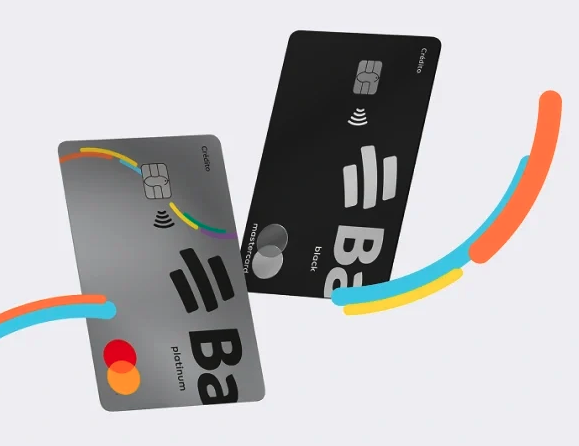

In [3]:
Image(filename = "img/tdc.png", width=1500, height=500)

# Introducción

In [4]:
# Obtener número de tarjetas vendidas por digital

sql = f"""
WITH outcome AS
  (SELECT year(f_venta) AS YEAR,
          month(f_venta) AS mes,
          year(f_venta)*10000 + month(f_venta)*100 + 1 AS f_venta_ym,
          count(*) AS num_tdc_new
   FROM resultados_vdm.sabana_ventas_digitales
   WHERE YEAR BETWEEN 2020 AND 2026
     AND prod IN ('TDC')
     AND tipo_venta = 'Digital'
   GROUP BY 1,
            2,
            3
   ORDER BY f_venta_ym DESC)
SELECT YEAR,
       mes,
       f_venta_ym,
       num_tdc_new,
       sum(num_tdc_new) OVER (PARTITION BY YEAR
                              ORDER BY YEAR, mes) AS num_tdc_new_cumsum_ym
FROM outcome
ORDER BY f_venta_ym DESC;
"""
df = helper.obtener_dataframe(sql)

2026-07-16 09:05:14 - [INFO] - Transcurrido: 1784210715, Tiempo de Refresco = 1000


------------------------------------------------------------
  i    tipo    nombre    estado     hora_inicio   duracion   
------------------------------------------------------------
 1/1 DATAFRAME        descargando   09:05:14 AM             

2026-07-16 09:06:33 - [INFO] - 79 filas, 5 columnas, 01:18.0 consultando, 00:00.7 descargando, 00:00.0 convirtiendo


 1/1 DATAFRAME         finalizado   09:05:14 AM     01:18.9 
------------------------------------------------------------


In [5]:
# Transformar la columna f_venta_ym a formato datetime
df['f_venta_ym'] = pd.to_datetime(df.f_venta_ym, format='%Y%m%d')

# Elegir sólo hasta junio de 2026
df = df[df['f_venta_ym'] <= '2026-06-01'].copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 78 entries, 1 to 78
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   year                   78 non-null     int64         
 1   mes                    78 non-null     int64         
 2   f_venta_ym             78 non-null     datetime64[ns]
 3   num_tdc_new            78 non-null     int64         
 4   num_tdc_new_cumsum_ym  78 non-null     int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 3.7 KB


# Cifras en perspectiva histórica, metas y proyecciones

In [6]:
# Crear periodo de tiempo
index_date = pd.date_range(start='2026-01-01', end='2026-12-31', freq='MS')
# index_date = pd.to_datetime(['2025-01-01', '2025-01-06', '2025-03-24', '2025-04-17', '2025-04-18'])
df_periodo_2 = pd.Series([1 for v in range(len(index_date))], index=index_date).reset_index()
df_periodo_2.columns = ['fecha', 'periodo_2']
df_periodo_2['valor'] = [29499, 29654, 30424, 30296, 33284, 31794, 33708, 32353, 33456, 31561, 31253, 31136]
df_periodo_2['valor'] = df_periodo_2['valor'].cumsum()
df_periodo_2['tipo_valor'] = 'meta_proyectada'
df_periodo_2.drop(columns=['periodo_2'], inplace=True)
df_data = df[['f_venta_ym', 'num_tdc_new_cumsum_ym']]
df_data.columns = ['fecha', 'valor']

df_data['tipo_valor'] = 'real'
df_plot = pd.concat([df_data, df_periodo_2]).reset_index(drop=True)
df_plot


,fecha,valor,tipo_valor
0,2026-06-01,162156,real
1,2026-05-01,136036,real
2,2026-04-01,113832,real
3,2026-03-01,83541,real
4,2026-02-01,54480,real
...,...,...,...
85,2026-08-01,251012,meta_proyectada
86,2026-09-01,284468,meta_proyectada
87,2026-10-01,316029,meta_proyectada
88,2026-11-01,347282,meta_proyectada


In [11]:


fig = px.line(df_plot, x="fecha", y="valor", color='tipo_valor', markers=True, template='simple_white', width=1600, height=800)
# fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución número de tarjetas vendidas digitalmente [acumulado año] vs meta proyectada año 2026",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de tarjetas vendidas digitalmente"
            ))
)
fig.add_annotation(x='2026-12-01', y=378418,
            text="Meta proyectada<br><b>378.418</b> número de tarjetas nuevas vendidas <br>acumuladas a diciembre 2026",
            showarrow=False,
            xanchor='left')
fig.add_annotation(x='2026-06-01', y=184951,
            text="Meta proyectada<br><b>184.951</b> número de tarjetas nuevas vendidas<br>acumuladas hasta junio 2026",
            showarrow=False,
            xanchor='left',
            xshift=3)
fig.add_annotation(x='2026-06-01', y=162361,
            text="Dato real<br><b>162.361</b> número de tarjetas nuevas vendidas<br>acumuladas hasta junio 2026<br><b>13.9% por debajo de la meta proyectada</b>",
            showarrow=False,
            xanchor='left',
            xshift=3,
            yshift=-55)
fig.show()

In [8]:


fig = px.line(df_plot, x="fecha", y="valor", color='tipo_valor', markers=True, template='simple_white', width=1600, height=800)
# fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución número de tarjetas vendidas acumuladas año por digital vs meta proyectada año 2026",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de tarjetas vendidas por digital"
            ))
)
fig.add_annotation(x='2026-12-01', y=378418,
            text="Meta proyectada<br><b>378.418</b> número de tarjetas nuevas vendidas <br>acumulados en diciembre 2026",
            showarrow=False,
            xanchor='left')
fig.add_annotation(x='2026-06-01', y=184951,
            text="Meta proyectada<br><b>184.951</b> número de tarjetas nuevas vendidas<br>acumulados hasta junio 2026",
            showarrow=False,
            xanchor='left',
            xshift=3)
fig.add_annotation(x='2026-06-01', y=162361,
            text="Dato real<br><b>162.361</b> número de tarjetas nuevas vendidas<br>acumulados hasta junio 2026<br><b>13.9% por debajo de la meta proyectada</b>",
            showarrow=False,
            xanchor='left',
            xshift=3,
            yshift=-55)
fig.show()

In [9]:
df.columns

Index(['year', 'mes', 'f_venta_ym', 'num_tdc_new', 'num_tdc_new_cumsum_ym'], dtype='object')

# Número de tarjetas vendidas mensualmente

In [10]:


fig = px.line(df, x="f_venta_ym", y="num_tdc_new", markers=True, template='simple_white', width=1600, height=800)
# fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución número de tarjetas vendidas mensualmente por digital",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de tarjetas vendidas mensualmente por digital"
            ))
)
# fig.add_annotation(x='2026-12-01', y=378418,
#             text="Meta proyectada<br><b>378.418</b> número de tarjetas nuevas vendidas <br>acumulados en diciembre 2026",
#             showarrow=False,
#             xanchor='left')
# fig.add_annotation(x='2026-06-01', y=184951,
#             text="Meta proyectada<br><b>184.951</b> número de tarjetas nuevas vendidas<br>acumulados hasta mayo 2026",
#             showarrow=False,
#             xanchor='left',
#             xshift=3)
# fig.add_annotation(x='2026-06-01', y=162361,
#             text="Dato real<br><b>162.361</b> número de tarjetas nuevas vendidas<br>acumulados hasta mayo 2026<br><b>13.9% por debajo de la meta proyectada</b>",
#             showarrow=False,
#             xanchor='left',
#             xshift=3,
#             yshift=-55)
fig.show()